In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')

# Set a professional plotting style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14

In [2]:
# Adjust the path assuming your notebook is in /notebooks and data is in /data
data_path = '../data/processed/gbpusd_15m.parquet'

print(f"Loading data from: {data_path}...")
df = pd.read_parquet(data_path)

# Ensure the index is a datetime object and sorted
if df.index.name != 'datetime' and 'datetime' in df.columns:
    df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

# 1. Calculate Log Returns (Continuous compounding)
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

# 2. Calculate Absolute and Squared Returns (Proxies for Volatility)
df['abs_return'] = df['log_return'].abs()
df['sq_return'] = df['log_return']**2

df.dropna(inplace=True)
print(f"Data Loaded Successfully!")
print(f"Total rows: {len(df):,}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")

Loading data from: ../data/processed/gbpusd_15m.parquet...
Data Loaded Successfully!
Total rows: 644,924
Date Range: 2000-05-30 23:00:00+00:00 to 2026-02-27 21:45:00+00:00


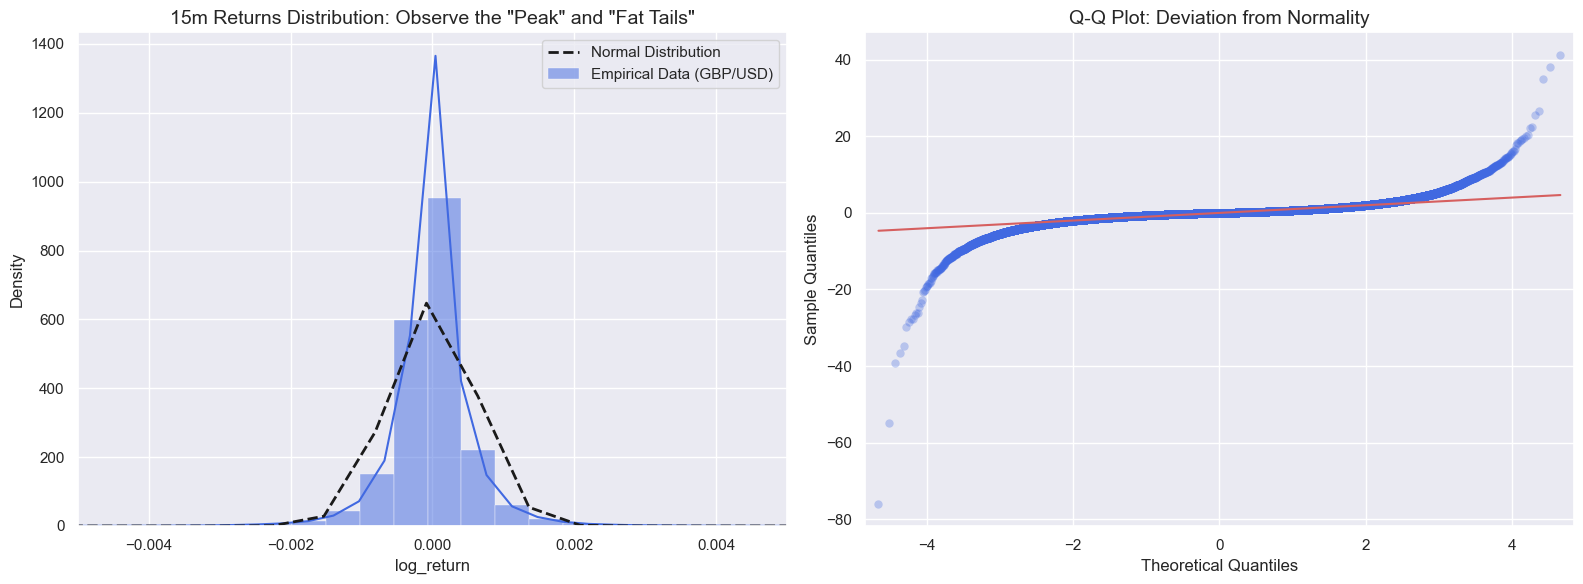

Kurtosis (Fat Tails severity): 114.02
Skewness (Directional bias): -1.16
CONCLUSION: If Kurtosis is high, traditional stop-losses are mathematically insufficient without dynamic buffers.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Kernel Density Estimate (KDE) vs Normal Distribution
sns.histplot(df['log_return'], bins=150, kde=True, stat="density", ax=axes[0], color='royalblue', label='Empirical Data (GBP/USD)')
mu, std = df['log_return'].mean(), df['log_return'].std()
x = np.linspace(df['log_return'].min(), df['log_return'].max(), 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'k--', linewidth=2, label='Normal Distribution')
axes[0].set_xlim([-0.005, 0.005]) # Zoomed in for 15m scale
axes[0].set_title('15m Returns Distribution: Observe the "Peak" and "Fat Tails"')
axes[0].legend()

# 2. Q-Q Plot (Quantile-Quantile)
sm.qqplot(df['log_return'], line='s', ax=axes[1], fit=True, markerfacecolor='royalblue', markeredgecolor='none', alpha=0.3)
axes[1].set_title('Q-Q Plot: Deviation from Normality')

plt.tight_layout()
plt.show()

# Calculate excess Kurtosis (Normal = 0. Anything > 3 is highly fat-tailed)
print(f"Kurtosis (Fat Tails severity): {df['log_return'].kurtosis():.2f}")
print(f"Skewness (Directional bias): {df['log_return'].skew():.2f}")
print("CONCLUSION: If Kurtosis is high, traditional stop-losses are mathematically insufficient without dynamic buffers.")

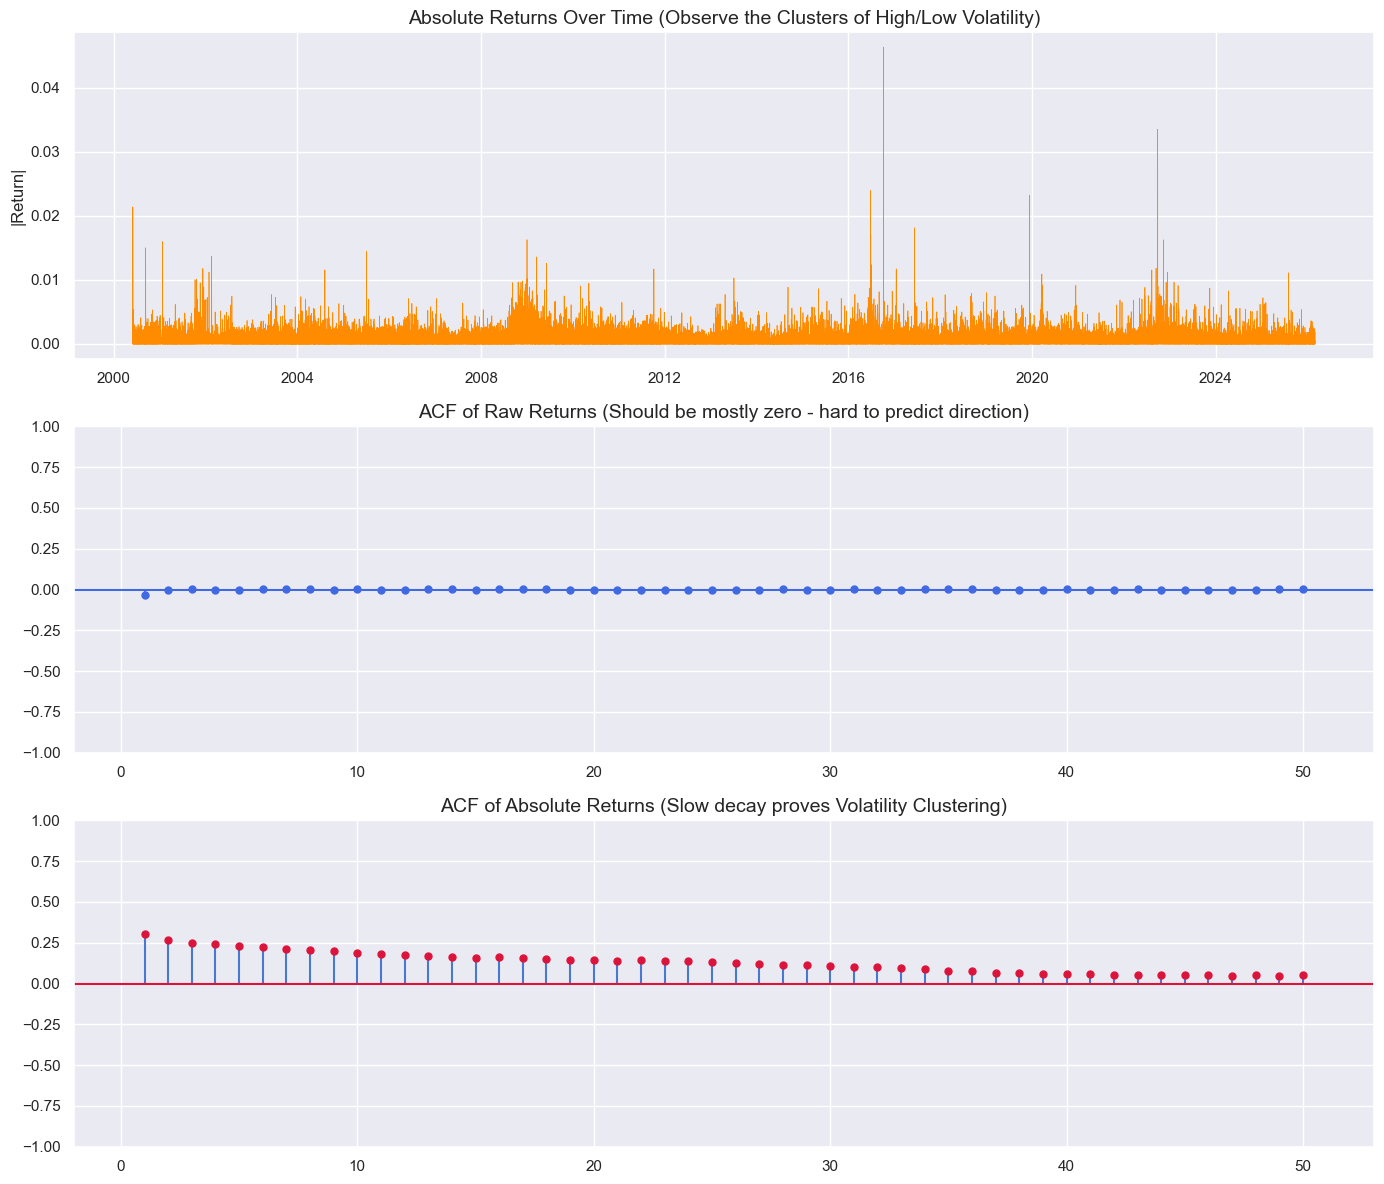

CONCLUSION: We cannot easily predict the next 15m candle's direction (Middle plot), but we CAN predict its size/volatility (Bottom plot).


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Visualizing Volatility over time (Zooming in on the last 50,000 bars for clarity)
sample_df = df.tail(1000000)
axes[0].plot(sample_df.index, sample_df['abs_return'], color='darkorange', linewidth=0.5)
axes[0].set_title('Absolute Returns Over Time (Observe the Clusters of High/Low Volatility)')
axes[0].set_ylabel('|Return|')

# 2. Autocorrelation (ACF) of RAW returns (Proves the market is directional-efficient)
plot_acf(df['log_return'], lags=50, ax=axes[1], zero=False, color='royalblue', title='ACF of Raw Returns (Should be mostly zero - hard to predict direction)')

# 3. Autocorrelation (ACF) of ABSOLUTE returns (Proves volatility is highly predictable)
plot_acf(df['abs_return'], lags=50, ax=axes[2], zero=False, color='crimson', title='ACF of Absolute Returns (Slow decay proves Volatility Clustering)')

plt.tight_layout()
plt.show()

print("CONCLUSION: We cannot easily predict the next 15m candle's direction (Middle plot), but we CAN predict its size/volatility (Bottom plot).")

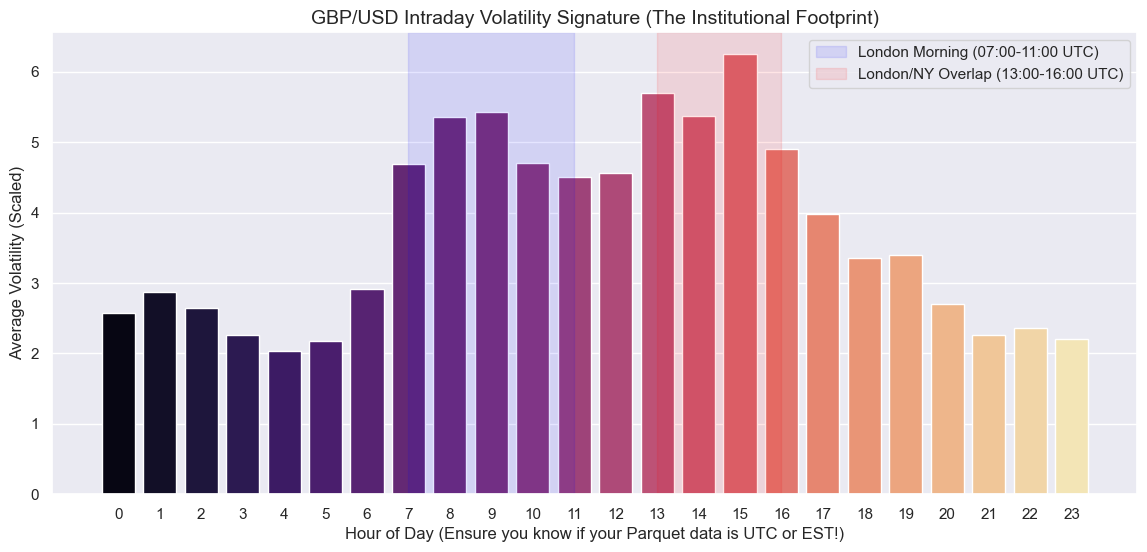

CONCLUSION: Your algorithm's risk engine must scale aggressively during the highlighted overlap zones.


In [5]:
# Extract the hour of the day
df['hour'] = df.index.hour

# Calculate average volatility per hour (Scaled up for readability)
hourly_volatility = df.groupby('hour')['abs_return'].mean() * 10000 

plt.figure(figsize=(14, 6))
sns.barplot(x=hourly_volatility.index, y=hourly_volatility.values, palette='magma')
plt.title('GBP/USD Intraday Volatility Signature (The Institutional Footprint)')
plt.xlabel('Hour of Day (Ensure you know if your Parquet data is UTC or EST!)')
plt.ylabel('Average Volatility (Scaled)')

# Highlight typical peak zones (Assuming data is UTC)
# Adjust these vertical spans if your data uses a different timezone
plt.axvspan(7, 11, color='blue', alpha=0.1, label='London Morning (07:00-11:00 UTC)')
plt.axvspan(13, 16, color='red', alpha=0.1, label='London/NY Overlap (13:00-16:00 UTC)')

plt.legend()
plt.show()

print("CONCLUSION: Your algorithm's risk engine must scale aggressively during the highlighted overlap zones.")